## Question: "How long do I need to integrate to detect a faint redshifted emission line at a target S/N?"

### Some NIRSpec Docs
- [Readout Patterns](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-instrumentation/nirspec-detectors/nirspec-detector-readout-modes-and-patterns#gsc.tab=0)
- [Recommended Strategies](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-observing-strategies/nirspec-detector-recommended-strategies#gsc.tab=0)

In [1]:
# Pandeia reference data
import os
os.environ["pandeia_refdata"] = "./data/pandeia_data-2026.2-jwst"
os.environ["PSF_DIR"] = "./data/pandeia_psfs-2026.2-jwst"
os.environ["PYSYN_CDBS"] = "./data/grp/redcat/trds"

# Exposure time calculator
from pandeia.engine.calc_utils import build_default_calc
from pandeia.engine.perform_calculation import perform_calculation

import matplotlib.pyplot as plt
import numpy as np

# Observing parameters
telescope = 'jwst'
instrument = 'nirspec'
mode = 'fixed_slit'
disperser = 'g395h'
filter = 'f290lp'
readout_pattern = 'nrsirs2'

# Detector (ngroup/nint fixed; nexp is solved for below)
ngroups = 190
nint = 6
max_nexp = 50

# Science goal
target_line_snr = 30.0 # required integrated line S/N
geometry = 'point' # source geometry

# Emission line
name = 'H alpha'
emission_line_center = 0.6563 # rest wavelength, microns
emission_line_width = 1000 # km/s FWHM
emission_line_strength = 2e-18 # erg/s/cm2 (integrated line flux)
redshift = 5

c_kms = 299792.458
obs_wavelength = emission_line_center * (1 + redshift) # observed-frame line center (um)
sigma_um = obs_wavelength * (emission_line_width / c_kms) / 2.3548  # Gaussian sigma (um)

# Exposure constraints
max_single_int = 1500 # max single integration time, s
max_single_exp = 10000 # max single exposure time, s

In [2]:
def build_calc(nexp):
    """Build a calc for the redshifted line at a given number of exposures (nexp)."""
    calc = build_default_calc(telescope, instrument, mode)
    calc['configuration']['instrument']['disperser'] = disperser
    calc['configuration']['instrument']['filter'] = filter
    calc['configuration']['detector']['readout_pattern'] = readout_pattern
    calc['configuration']['detector']['ngroup'] = ngroups
    calc['configuration']['detector']['nint'] = nint
    calc['configuration']['detector']['nexp'] = nexp
    calc['background_level'] = 'low'

    scene = calc['scene'][0]
    scene['shape']['geometry'] = geometry
    scene['spectrum']['sed'] = {'sed_type': 'no_continuum'} # zero continuum (no normalization needed).
    scene['spectrum']['redshift'] = 0
    scene['spectrum']['lines'] = [{
        'id': 0, 
        'name': name, 
        'emission_or_absorption': 'emission',
        'center': obs_wavelength, # line at its observed redshifted wavelength
        'width': emission_line_width, # km/s FWHM
        'strength': emission_line_strength, 
        'profile': 'gaussian'}]
    return calc

def integrated_line_snr(report, nsigma=3.0):
    """Continuum-subtracted integrated S/N over a fixed +/- nsigma line window.

    Sums the (continuum-subtracted) flux across the line and divides by the
    quadrature-summed noise. The window is fixed and signal-independent, so the
    S/N is not biased -- unlike a `flux > noise` selection, which cherry-picks
    the favorable pixels and inflates the result.
    """
    
    # Extract the 1D spectrum and noise from the report
    wave = np.asarray(report['1d']['extracted_flux'][0])
    flux = np.asarray(report['1d']['extracted_flux'][1])
    noise = np.asarray(report['1d']['extracted_noise'][1])
    
    # Define the line window and continuum region
    dist = np.abs(wave - obs_wavelength) # distance from line center (um)
    line = dist <= nsigma * sigma_um # line window
    side = (dist > nsigma * sigma_um) & (dist <= (nsigma + 4) * sigma_um) #
    continuum = np.median(flux[side]) if side.any() else 0.0 # local baseline
    
    # Compute the integrated line S/N
    signal = np.sum(flux[line] - continuum)
    noise = np.sqrt(np.sum(noise[line] ** 2))
    snr = signal / noise
    return snr


def solve_nexp_for_line_snr(target_snr, min_nexp=1, max_nexp=50):
    """Smallest number of exposures reaching integrated line S/N >= target_snr.

    Line S/N grows as sqrt(total time) ~ sqrt(nexp), so one reference exposure
    predicts how many are needed
    """
    
    # For each nexp ...
    for nexp in range(min_nexp, max_nexp + 1):
        
        # ... Perform the calculation and measure the integrated line S/N    
        report = perform_calculation(build_calc(nexp))
        snr = integrated_line_snr(report)
        spec = report['information']['exposure_specification']
        
        # Print the result for this nexp
        print(f"[search] nexp={nexp}, total_exp={spec['total_exposure_time']:.0f}s, "
              f"line S/N={snr:.2f}")
        
        # Check if reached the target S/N
        if snr >= target_snr:
            return report, snr, nexp
    return None

/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/report.py:746: RuntimeWarning: divide by zero encountered in divide
  sn = self.extracted['extracted_flux'] / self.extracted['extracted_noise']
/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/projection.py:78: RuntimeWarning: invalid value encountered in divide
  self.detector_sn = (s - self.bg_pix) / n


[search] nexp=1, total_exp=8890s, line S/N=13.91


/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/report.py:746: RuntimeWarning: divide by zero encountered in divide
  sn = self.extracted['extracted_flux'] / self.extracted['extracted_noise']
/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/projection.py:78: RuntimeWarning: invalid value encountered in divide
  self.detector_sn = (s - self.bg_pix) / n


[search] nexp=2, total_exp=17780s, line S/N=19.67


/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/report.py:746: RuntimeWarning: divide by zero encountered in divide
  sn = self.extracted['extracted_flux'] / self.extracted['extracted_noise']
/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/projection.py:78: RuntimeWarning: invalid value encountered in divide
  self.detector_sn = (s - self.bg_pix) / n


[search] nexp=3, total_exp=26670s, line S/N=24.09


/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/report.py:746: RuntimeWarning: divide by zero encountered in divide
  sn = self.extracted['extracted_flux'] / self.extracted['extracted_noise']
/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/projection.py:78: RuntimeWarning: invalid value encountered in divide
  self.detector_sn = (s - self.bg_pix) / n


[search] nexp=4, total_exp=35560s, line S/N=27.82


/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/report.py:746: RuntimeWarning: divide by zero encountered in divide
  sn = self.extracted['extracted_flux'] / self.extracted['extracted_noise']
/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/projection.py:78: RuntimeWarning: invalid value encountered in divide
  self.detector_sn = (s - self.bg_pix) / n


[search] nexp=5, total_exp=44450s, line S/N=31.10

=== nirspec g395h/f290lp: time to detect H alpha at z=5 ===
Line: 3.9378 um, 1000 km/s, 2.0e-18 erg/s/cm2
To reach integrated line S/N = 30.0:
  nexp = 5 (ngroup=190, nint=6, readout=nrsirs2)
  total exposure time = 44450 s (12.3 h)
  achieved line S/N = 31.10


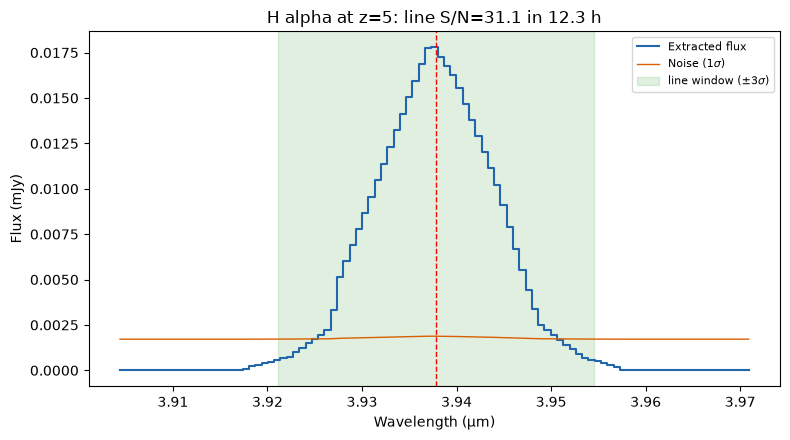

In [3]:
# Solve for the exposure needed, then report and plot the detected line
result = solve_nexp_for_line_snr(target_line_snr, max_nexp=max_nexp)

# Check if the target S/N was reached and report the results
if result is None:
    print(f"Target line S/N={target_line_snr} not reached within nexp<={max_nexp}. "
          f"Try: brighter line, deeper detector settings, or a different disperser.")

# Report the results for the best solution found
else:
    report, snr, nexp = result
    spec = report['information']['exposure_specification'] # Extract exposure specification
    single_int = spec['exposure_time'] / spec['nint'] # Single integration time (s)
    
    # Print the results
    print(f"\n=== {instrument} {disperser}/{filter}: time to detect {name} at z={redshift} ===")
    print(f"Line: {obs_wavelength:.4f} um, {emission_line_width} km/s, "
          f"{emission_line_strength:.1e} erg/s/cm2")
    print(f"To reach integrated line S/N = {target_line_snr}:")
    print(f"  nexp = {nexp} (ngroup={spec['ngroup']}, nint={spec['nint']}, "
          f"readout={spec['readout_pattern']})")
    print(f"  total exposure time = {spec['total_exposure_time']:.0f} s "
          f"({spec['total_exposure_time']/3600:.1f} h)")
    print(f"  achieved line S/N = {snr:.2f}")
    
    # Check if the single integration or exposure times exceed the recommended limits
    if single_int > max_single_int:
        print(f"  WARNING: single integration {single_int:.0f}s > {max_single_int}s (reduce ngroup)")
    if spec['exposure_time'] > max_single_exp:
        print(f"  WARNING: single exposure {spec['exposure_time']:.0f}s > {max_single_exp}s (reduce nint)")

    # Plot the extracted spectrum around the line
    wave = np.asarray(report['1d']['extracted_flux'][0])
    flux = np.asarray(report['1d']['extracted_flux'][1])
    noise = np.asarray(report['1d']['extracted_noise'][1])
    window = np.abs(wave - obs_wavelength) <= 6 * sigma_um # window around the line
    
    # Plot the extracted spectrum and noise around the line
    plt.figure(figsize=(8, 4.5))
    plt.plot(wave[window], flux[window], color='#2166ac', label='Extracted flux', drawstyle='steps-mid')
    plt.plot(wave[window], noise[window], color='#d95f02', lw=1, label=r'Noise (1$\sigma$)')
    plt.axvspan(obs_wavelength - 3 * sigma_um, obs_wavelength + 3 * sigma_um,
                color='green', alpha=0.12, label=r'line window ($\pm3\sigma$)')
    plt.axvline(obs_wavelength, color='red', ls='--', lw=1)
    plt.xlabel('Wavelength (µm)')
    plt.ylabel('Flux (mJy)')
    plt.title(f'{name} at z={redshift}: line S/N={snr:.1f} in '
              f'{spec["total_exposure_time"]/3600:.1f} h')
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()